# Conditional VAE's

The objective of this mini-project is to define and train a Conditional VAE (CVAE).

## Introduction

According to the lesson, an autoencoder is an "unsupervized (= data without labels) learning technique for the task of representation learning, latent representation or transferable representation". The architecture of this Neural Network is first composed with an encoder that compressed the data to a thiner size, then the data passes through a bottleneck, the latent space, and finally, a decoder try rebuilt the original data. The problem of the classical VAE is that we can't control the output generated. For example, a VAE trained on MNIST cannot producee only 3 or 8, only samples betweeen 0 and 9.

To overcome this problem, one can introduce the Conditional VAE that allows a conditionned output from specific input instead of generating only randomly. To do so, one can introduce supervised elements and train the model over labelled data to conditione the output of the decoder.

![difference cvae vae]( of-the-difference-between-VAE-and-CVAE-In-CVAE-both-the-encoder-and-decoder-part.png "Difference between CVAE and VAE" )

## Fashion-MNIST dataset

The [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset consists of Zalando's arcticle. Each image is a **28x28 pixel** grayscale image, associated with a label from 10 classes. The training set contains **60,000 images** while the test set contains **10,000 images**. This dataset is similar to the MNIST one.

The MNIST dataset can be downloaded from the **torchvision** library.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
from torchvision import datasets, transforms
batch_size = 128

# Data loading
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.FashionMNIST(root='data_cvae', train=True, transform=transform, download=True)
test_dataset = datasets.FashionMNIST(root='data_cvae', train=False, transform=transform, download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

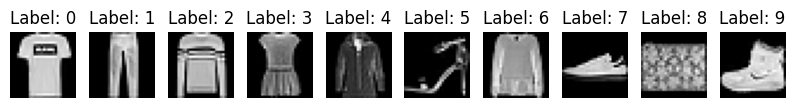

0


In [ ]:
# Plot 1 random image from the Fashion-MNIST train dataset for each label
def plot_images(img_dataset):
    """Plots 1 images from each labels from the given dataset

    Args:
        img_dataset (torch.utils.data.Dataset): The dataset to plot images from
    """

    labels_found = {}
    idx = 0
    while len(labels_found) < len(img_dataset.classes) and idx < len(img_dataset):
        _, label = img_dataset[idx]
        if label not in labels_found:
            labels_found[label] = idx
        idx += 1

    cols, rows = 10, 1 
    figure = plt.figure(figsize=(10, 5))

    for i, (label, img_idx) in enumerate(sorted(labels_found.items()), 1):
        img, label = img_dataset[img_idx]
        figure.add_subplot(rows, cols, i)
        plt.title(f'Label: {label}')
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap="gray")
    plt.show()

plot_images(train_dataset)

## Adaptation of the convolutional VAE

Firstly, we recuperated the convolutional VAE from the practical and we adapted it to have a conditional one. The loss function used is exactly the same as the VAE one, as we read it in some articles.

"A CVAE is trained with exactly the same loss function as it’s non-conditioned buddy. Here is the loss" [arcticle 1](https://medium.com/@sofeikov/implementing-conditional-variational-auto-encoders-cvae-from-scratch-29fcbb8cb08f)

In [4]:
# Hyperparameters
batch_size = 128                    # High batch size to avoid noisy gradients
latent_dim = 2                      # dimension of the latent space
learning_rate = 1e-2                # 
epochs_liste = [5, 10, 30, 50]            # A small number of epochs for quick testing - may be increased later / for eppoch in epochs[1:]
kl_weights = [0, 1, 10, 100, 1000]  # Different weights for the KL divergence term

import pandas as pd
DoE_unif3 = pd.read_csv('DoE.csv')
#DoE_unif3

dic_lr = {'mean': 0.001, 'std': 0.01}
dic_batch_size = {'mean': 128, 'std': 100}
dic_epochs = {'mean': 30, 'std': 100}

dicts = [dic_lr, dic_batch_size, dic_epochs]
vars = ['lr', 'batch', 'epoch']
DoE = {'lr': [], 'batch': [], 'epoch': []}

for i in range(3):

    dic = dicts[i]
    var = vars[i]

    m = dic['mean']
    s = dic['std']
    var_unif = DoE_unif3[var]
    DoE[var] = m + s * var_unif 

DoE = pd.DataFrame(DoE)
DoE
DoE['batch'] = DoE['batch'].astype(int)
DoE['epoch'] = DoE['epoch'].astype(int)
DoE['lr'] = np.round(DoE['lr'], 4)

DoE

In [5]:
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim=10):
        super(ConditionalVAE, self).__init__()
        self.latent_dim = latent_dim
        self.label_embedding = nn.Embedding(10, 16) # sert à créer un vecteur des labels
        
        # Encoder used initially from the practical
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 14, 14)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # Output: (64, 7, 7)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # Output: (128, 4, 4)
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        
        # Fully connected layers for mean and log variance
        self.fc_mu = nn.Linear(128 * 4 * 4 + 16, latent_dim) 
        self.fc_logvar = nn.Linear(128 * 4 * 4 + 16, latent_dim) 
        self.fc_decode = nn.Linear(latent_dim + 16, 128 * 4 * 4) 
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),  # Output: (64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # Output: (32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),  # Output: (1, 28, 28)
            nn.Sigmoid()
        )
    
    def encode(self, x, y):
        x = self.encoder(x)
        x = x.view(-1, 128 * 4 * 4) # Flatten the output of the convolutional layers
        y = self.label_embedding(y)
        mu = self.fc_mu(torch.cat((x,y),dim=1))
        logvar = self.fc_logvar(torch.cat((x,y),dim=1))
        return mu, logvar
    

    def sample(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z, y, hot_shot = False):
        if hot_shot == False:              # to generate samples
            y = self.label_embedding(y) 
        x = self.fc_decode(torch.cat((z,y),dim=1))
        x = x.view(-1, 128, 4, 4)  # Reshape to (128, 4, 4) for the decoder
        x = self.decoder(x)
        return x

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.sample(mu, logvar)
        return self.decode(z, y), mu, logvar 
    

### The loss function

$$Loss = \text{BCE} + \beta \cdot \text{KLD}$$

 The loss function that we use is composed with a reconstruction component and a regularization component.
 The Binary Cross Entropy term measures the fidelity of the output $\hat{x}$ compared with the input $x$.

$$\text{BCE}(x, \hat{x}) = -\sum [x \log(\hat{x}) + (1-x) \log(1-\hat{x})]$$

The regularization term KLD regularized the latent space by forcing the learnt distribution $q(z|x)$ to be closer to a normal distribution $\mathcal{N}(0, 1)$

$$\text{KLD} = -\frac{1}{2} \sum_{j=1}^{m} (1 + \log(\sigma_j^2) - \mu_j^2 - \sigma_j^2)$$

The weight parameter $\beta$ controls the importance of the regularization term. It is a trade-off between the importance of the quality of the reconstruction and the structure of the latent space.

In [6]:
def loss_function(recon_x, x, mu, logvar, beta=1):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + beta * KLD, BCE, KLD

In [7]:
# Function to plot the loss function with its separate components
def plot_loss(epochs, losses, BCE, kl_weight, KLD, val_losses):
    # Création d'une figure avec 2 lignes et 1 colonne
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    epochs_range = range(1, epochs + 1)

    # Premier graphique : Pertes globales et BCE
    ax1.plot(epochs_range, losses, marker='o', label='Training Loss')
    ax1.plot(epochs_range, BCE, marker='+', label='Training BCE')
    ax1.plot(epochs_range, val_losses, marker='s', label='Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_title('CVAE Training vs Validation Loss and BCE')
    ax1.legend()
    ax1.grid(True)

    # Deuxième graphique : Terme de régularisation KLD
    # Calcul direct avec une liste en compréhension (plus rapide)
    second_terme = [k * kl_weight for k in KLD]
    
    ax2.plot(epochs_range, second_terme, marker='+', color='orange', label='Training beta*KLD')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.set_title('Terme de régularisation (KLD weighted)')
    ax2.legend()
    ax2.grid(True)

    # Ajuste l'espacement pour éviter que les titres ne chevauchent les axes
    plt.tight_layout()
    plt.show()

# Function to plot latent space
def plot_latent_space(model, kl_weight):
    model.eval()
    with torch.no_grad():
        test_loader = DataLoader(dataset=test_dataset, batch_size=10000, shuffle=False)
        data, labels = next(iter(test_loader))
        data = data.to(device)
        label = labels.to(device)
        mu, logvar = model.encode(data, label)
        z = mu  # For visualization, we use the mean
        z = z.cpu().numpy()
        labels = labels.numpy()
        
        plt.figure(figsize=(8,6))
        scatter = plt.scatter(z[:, 0], z[:, 1], c=labels, cmap='tab10', alpha=0.7)
        plt.colorbar(scatter, ticks=range(10))
        plt.clim(-0.5, 9.5)
        plt.title(f'Latent Space with KL Weight = {kl_weight}')
        plt.xlabel('Z1')
        plt.ylabel('Z2')
        #file_name = 'plot_latent_space_'+ name
        #file_path = figure_path + file_name + '_kl_weight_'+str(kl_weight)+'.png'
        #plt.savefig(file_path)
        plt.show()

# Train the model for the given number of epochs
# At the end of each epoch, print the training loss



We train the model for different regularization weights and we plot the latent spaces and loss function with a separation for each components associated.

In [12]:
# Initialize the CVAE model and the Adam optimizer
from xml.parsers.expat import model
import os

cvae = ConditionalVAE(latent_dim=latent_dim)
cvae.to(device)
optimizer = optim.Adam(cvae.parameters(), lr=learning_rate)

for epochs in epochs_liste[1:]:
    print(f'\nTraining VAE with Epoch = {epochs}')

    for kl_weight in kl_weights :
        print(f'\nTraining VAE with KL Weight = {kl_weight}')

        losses = []  # liste pour stocker les pertes
        BCE = []
        KLD = []
        val_losses = [] # liste pour stocker la validation loss

        for epoch in range(1, epochs + 1):
            cvae.train()
            running_loss = 0.0
            running_bce = 0.0
            running_kld = 0.0

            for batch_idx, (data, label) in enumerate(train_loader): # label c'est le y
                data = data.to(device)
                label = label.to(device)
                optimizer.zero_grad()
                recon_batch, mu, logvar = cvae(data, label)
                loss, bce, kld = loss_function(recon_batch, data, mu, logvar, kl_weight)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                running_bce += bce.item()
                running_kld += kld.item()

            epoch_loss = running_loss / len(train_loader.dataset)
            epoch_bce = running_bce / len(train_loader.dataset)
            epoch_kld = running_kld / len(train_loader.dataset)

            losses.append(epoch_loss)  # on sauvegarde la perte
            BCE.append(epoch_bce)
            KLD.append(epoch_kld)


            # --- Validation ---
            cvae.eval()
            val_running_loss = 0.0
            with torch.no_grad():
                for batch_idx, (data, label) in enumerate(test_loader):
                    data = data.to(device)
                    label = label.to(device)
                    recon_batch, mu, logvar = cvae(data, label)
                    val_loss, _, _ = loss_function(recon_batch, data, mu, logvar)
                    val_running_loss += val_loss.item()
            
            epoch_val_loss = val_running_loss / len(test_loader.dataset)
            val_losses.append(epoch_val_loss)

            print(f'Epoch {epoch}, Training loss: {epoch_loss:.4f}')
        
        os.makedirs(f'epochs/{epochs}/', exist_ok=True)
        torch.save(cvae.state_dict(), f'epochs/{epochs}/cvae_weights_epoch_{epochs}_kl_weight_{kl_weight}.pth')

        #lot_latent_space(cvae, kl_weight)
        #plot_loss(epochs, losses, BCE, kl_weight, KLD, val_losses)


Training VAE with Epoch = 10

Training VAE with KL Weight = 0
Epoch 1, Training loss: 262.9208
Epoch 2, Training loss: 251.0077
Epoch 3, Training loss: 249.4088
Epoch 4, Training loss: 248.5982
Epoch 5, Training loss: 247.8798
Epoch 6, Training loss: 247.5257
Epoch 7, Training loss: 247.2590
Epoch 8, Training loss: 246.8846
Epoch 9, Training loss: 246.5342
Epoch 10, Training loss: 246.3001

Training VAE with KL Weight = 1
Epoch 1, Training loss: 256.5315
Epoch 2, Training loss: 252.9943
Epoch 3, Training loss: 252.5115
Epoch 4, Training loss: 252.2086
Epoch 5, Training loss: 252.0329
Epoch 6, Training loss: 251.9644
Epoch 7, Training loss: 251.7656
Epoch 8, Training loss: 251.6980
Epoch 9, Training loss: 251.5543
Epoch 10, Training loss: 251.5067

Training VAE with KL Weight = 10
Epoch 1, Training loss: 278.4811
Epoch 2, Training loss: 277.6639
Epoch 3, Training loss: 277.5879
Epoch 4, Training loss: 277.4212
Epoch 5, Training loss: 277.4018
Epoch 6, Training loss: 277.5018
Epoch 7, T

KeyboardInterrupt: 

In [ ]:
weights_path="./epochs/30/cvae_weights_epoch_30_kl_weight_1.pth"

cvae = ConditionalVAE(latent_dim=latent_dim).to(device)
cvae.load_state_dict(torch.load(weights_path, map_location=device))
cvae.eval()
cvae.to(device)

ConditionalVAE(
  (label_embedding): Embedding(10, 16)
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
  )
  (fc_mu): Linear(in_features=2064, out_features=2, bias=True)
  (fc_logvar): Linear(in_features=2064, out_features=2, bias=True)
  (fc_decode): Linear(in_features=18, out_features=2048, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [31]:
labels = range(0,10)
n_per_label = 5

samples_labels = [k for k in labels for _ in range(n_per_label)]
print(samples_labels)

[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9]


In [32]:
num_samples= len(samples_labels)
y= torch.tensor(samples_labels).to(device)
    
with torch.no_grad():
    
    z = torch.randn(num_samples, latent_dim).to(device)

    generated = cvae.decode(z, y )

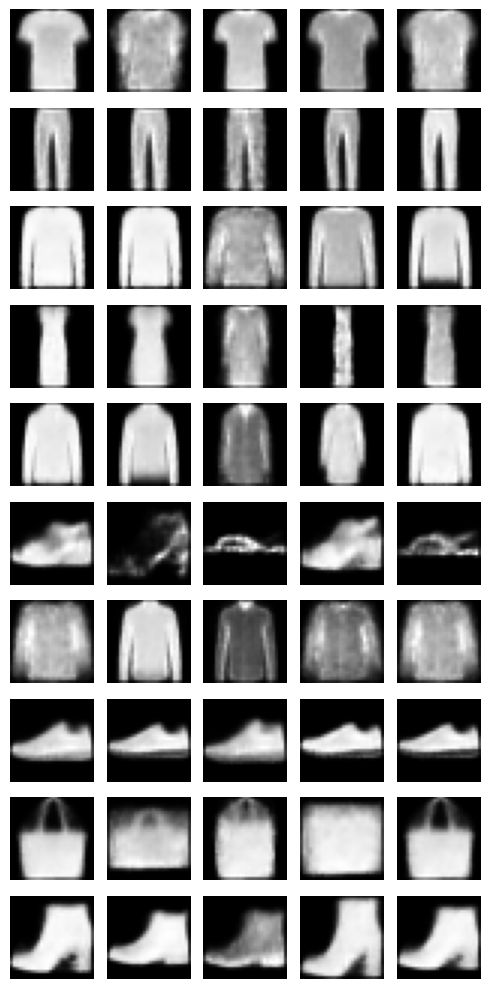

In [33]:
import matplotlib.pyplot as plt

generated = generated.cpu()

fig, axes = plt.subplots(10, n_per_label, figsize=(n_per_label, 10))

idx = 0
for i in range(10):
    for j in range(n_per_label):
        axes[i, j].imshow(generated[idx, 0], cmap="gray")
        axes[i, j].axis("off")
        idx += 1

plt.tight_layout()
plt.show()
